# Feature Evaluation - Crypto Perpetuals Funding

A perpetual futures contract has no expiry, so instead of converging to a spot price at
settlement it is pulled toward it by a periodic cash payment between longs and shorts called
**funding**. On Binance that payment settles every eight hours. The features built in the two
previous notebooks describe how rich that payment is, how far the contract trades from the spot
index, and how volatile both have been. This notebook asks the first question anyone should ask
of a feature before training on it: taken one at a time, does it say anything about what the
contract returns over the next eight hours?

The method is univariate screening. Each feature is scored on its own, the scores are corrected
for the fact that many features were searched, and the result is a per-feature record. It is
deliberately not a feature-selection step: nothing here removes a column from what the model
notebooks train on.

**Reads** `features/financial.parquet` (notebook 03), `features/model_based.parquet`
(notebook 04) and `labels/fwd_ret_8h.parquet` (notebook 02).
**Writes** `evaluation/triage_ledger.parquet`, one row per feature carrying its evidence and its
decision, and `evaluation/ic_timeseries.parquet`, the score series the ledger summarizes.

**Learning objectives**:
- Build the frame a walk-forward evaluation is allowed to use, so that no feature is scored on a
  period the model that produced it was trained on, and no score reaches the period held back
  for the final test.
- Measure how well a feature ranks the perpetuals against each other at one moment, repeat that
  at every moment, and average the result into a single number with an honest error bar.
- Read the same evidence a second way, one validation year at a time, to tell a feature that
  works throughout from one that worked once.
- Adjust the significance of forty scores for the fact that forty were looked at, and say what
  that adjustment costs.
- Record a decision per feature, with the evidence that produced it, in a form the strategy
  synthesis in Chapter 20 can read.

**Book reference**: Chapter 7, Section 7.3 (Univariate feature-label evaluation) and
Section 7.4 (Search accounting and multiple testing).

**Prerequisites**: [`02_labels`](02_labels.ipynb),
[`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb).

In [1]:
"""Evaluate crypto financial and temporal features on canonical validation folds."""

import warnings
from datetime import timedelta

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from IPython.display import display
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from scipy.stats import norm, spearmanr

from case_studies.utils.feature_engineering import assign_families, families_from_config
from utils.cv_splits import load_evaluation_config
from utils.modeling import load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.style import COLORS, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

In [2]:
MAX_SYMBOLS = 0

## Settings

Everything the case study has already decided is read from `config/setup.yaml` rather than
retyped here, so this notebook cannot end up screening a different label, a different holdout
boundary or a different redundancy threshold than the notebooks around it.

Four settings are this notebook's own, and each one decides something:

- **Minimum cross-section, 10 perpetuals.** A rank correlation is computed across the contracts
  quoted at one moment. The universe is nineteen contracts, and a rank correlation over a
  handful of them is mostly noise, so a settlement offering fewer than ten usable pairs
  contributes no score rather than a bad one. Section 2 shows how often that bites.
- **Minimum score count, 20 settlements.** A feature needs a score series long enough to average
  before it gets a row in the ledger.
- **HAC bandwidth, one funding day.** Explained where it is used, in section 4.
- **Exploration threshold on the average score.** Printed with the other bound settings below
  and explained where it is used, in section 8.

In [3]:
CASE_STUDY_ID = "crypto_perps_funding"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as _f:
    setup_config = yaml.safe_load(_f)
PRIMARY_LABEL = setup_config["labels"]["primary"]
BAR_HOURS = setup_config["features"]["bar_hours"]
REDUNDANCY_CUT = setup_config["features"]["redundancy_cut"]
FAMILY_REGISTER = families_from_config(setup_config)

JOIN_COLS = ["timestamp", "symbol"]
MIN_CROSS_SECTION = min(10, MAX_SYMBOLS) if MAX_SYMBOLS else 10
MIN_IC_PERIODS = 20
HAC_MAXLAGS = 24 // BAR_HOURS
IC_THRESHOLD = 0.005
N_QUANTILES = 5

print(f"screening label {PRIMARY_LABEL} on {BAR_HOURS}-hour settlement bars")
print(f"minimum cross-section {MIN_CROSS_SECTION}, minimum score count {MIN_IC_PERIODS}")
print(f"HAC bandwidth {HAC_MAXLAGS} settlements, exploration threshold {IC_THRESHOLD}")
print(f"redundancy threshold {REDUNDANCY_CUT} and {N_QUANTILES} groups per settlement")

screening label fwd_ret_8h on 8-hour settlement bars
minimum cross-section 10, minimum score count 20
HAC bandwidth 3 settlements, exploration threshold 0.005
redundancy threshold 0.7 and 5 groups per settlement


## 1. The frame this notebook is allowed to score on

The case study trains with **walk-forward cross-validation**: the history is cut into folds,
each fold trains on a block of time and is tested on the block that follows it, and the whole
arrangement is repeated further along the history. The folds stop short of the end: a final
stretch of history, the **holdout**, is reserved for one measurement of the finished strategy,
several notebooks from here.

Two constraints follow, and together they fix which rows may be scored.

First, the five features from notebook 04 are themselves model output: a volatility model and a
regime model are fitted inside each fold's training block and then run forward. A row therefore
has a different value for those five columns depending on which fold you are in, and it is out
of sample only in the fold whose training block ended before it. So each row enters exactly
once, carrying the version of those columns belonging to the fold that tests it.

Second, a feature scored at time `t` is scored against the return realized by `t` plus eight
hours. Reading a return that lands inside the holdout would spend the holdout on a diagnostic.
`load_modeling_dataset` derives the folds through `generate_cv_splits`, which ends the last
validation block one label horizon before the holdout begins; the check below confirms it.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
financial = pl.read_parquet(CASE_DIR / "features" / "financial.parquet")
financial_cols = [name for name in financial.columns if name not in JOIN_COLS]
temporal_cols = mds.temporal_feature_names

assert set(mds.feature_names) == set(financial_cols) | set(temporal_cols)
assert mds.temporal_by_fold is not None

symbols = mds.dataset["symbol"].unique().to_list()
base_frame = mds.dataset.select([*JOIN_COLS, *financial_cols, mds.label_col])
temporal_by_fold = pl.from_pandas(mds.temporal_by_fold).filter(pl.col("symbol").is_in(symbols))

validation_frames = []
for split in mds.splits:
    base = base_frame.filter(
        pl.col("timestamp").is_between(split["val_start"], split["val_end"], closed="both")
    )
    fold_temporal = temporal_by_fold.filter(pl.col("fold") == split["fold"]).select(
        [*JOIN_COLS, *temporal_cols]
    )
    fold_temporal = fold_temporal.with_columns(
        pl.col("timestamp").cast(base.schema["timestamp"])
    ).unique(subset=JOIN_COLS)
    frame = base.join(fold_temporal, on=JOIN_COLS, how="left").with_columns(
        pl.lit(split["fold"]).alias("cv_fold")
    )
    validation_frames.append(frame)

eval_panel = pl.concat(validation_frames).sort(["timestamp", "symbol"])
assert eval_panel.select(JOIN_COLS).is_duplicated().sum() == 0
assert eval_panel.columns == [*JOIN_COLS, *financial_cols, mds.label_col, *temporal_cols, "cv_fold"]

holdout_start = (
    pl.Series([load_evaluation_config(CASE_STUDY_ID)["holdout_start"]])
    .str.to_datetime()
    .dt.replace_time_zone("UTC")[0]
)
assert eval_panel["timestamp"].max() + timedelta(hours=BAR_HOURS) < holdout_start

print(f"{len(financial_cols)} features from notebook 03, {len(temporal_cols)} from notebook 04")
print(f"{len(eval_panel):,} rows, {eval_panel['symbol'].n_unique()} perpetuals")
print(f"{eval_panel['timestamp'].n_unique():,} settlements over {len(mds.splits)} validation folds")
for split in mds.splits:
    print(f"  fold {split['fold']}: {split['val_start']:%Y-%m-%d} to {split['val_end']:%Y-%m-%d}")
print(
    f"last settlement scored {eval_panel['timestamp'].max():%Y-%m-%d %H:%M}, "
    f"holdout opens {holdout_start:%Y-%m-%d %H:%M}"
)

39 features from notebook 03, 5 from notebook 04
35,280 rows, 19 perpetuals
2,189 settlements over 2 validation folds
  fold 0: 2023-01-01 to 2023-12-31
  fold 1: 2022-01-01 to 2022-12-31
last settlement scored 2023-12-31 08:00, holdout opens 2024-01-01 00:00


## 2. What is actually in the panel

Every number below rests on how many contracts are quoted side by side at each settlement, so
that is worth seeing before any of it. This is an **unbalanced panel**: a perpetual enters on
the date the exchange listed it and there is no history before that. Three of the nineteen
listed part-way through the two validation years.

In [5]:
universe = (
    eval_panel.group_by("symbol")
    .agg(
        pl.col("timestamp").min().alias("first settlement"),
        pl.col("timestamp").max().alias("last settlement"),
        pl.len().alias("settlements"),
    )
    .with_columns(
        (pl.col("settlements") / eval_panel["timestamp"].n_unique()).alias("share of window")
    )
    .sort("first settlement", "symbol")
)
display(universe)

symbol,first settlement,last settlement,settlements,share of window
str,"datetime[ms, UTC]","datetime[ms, UTC]",u32,f64
"""ADAUSDT""",2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC,1996,0.911832
"""ATOMUSDT""",2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC,2096,0.957515
"""AVAXUSDT""",2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC,1995,0.911375
"""BTCUSDT""",2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC,2003,0.91503
"""COMPUSDT""",2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC,2003,0.91503
…,…,…,…,…
"""BNBUSDT""",2022-01-04 08:00:00 UTC,2023-12-31 08:00:00 UTC,1968,0.899041
"""AAVEUSDT""",2022-01-11 08:00:00 UTC,2023-12-31 08:00:00 UTC,1893,0.864778
"""INJUSDT""",2022-09-16 08:00:00 UTC,2023-12-31 08:00:00 UTC,1228,0.560987


Listing dates are not the whole story. Notebook 03 emits a row only where every one of its
thirty-nine features is complete, so a contract also leaves the panel while any of its windows
is filling, and the longest of those windows spans ninety settlements. The effect on this
notebook is not spread evenly: the cross-section thins into two long stretches where fewer than
ten contracts are left, and every score below skips those settlements entirely.

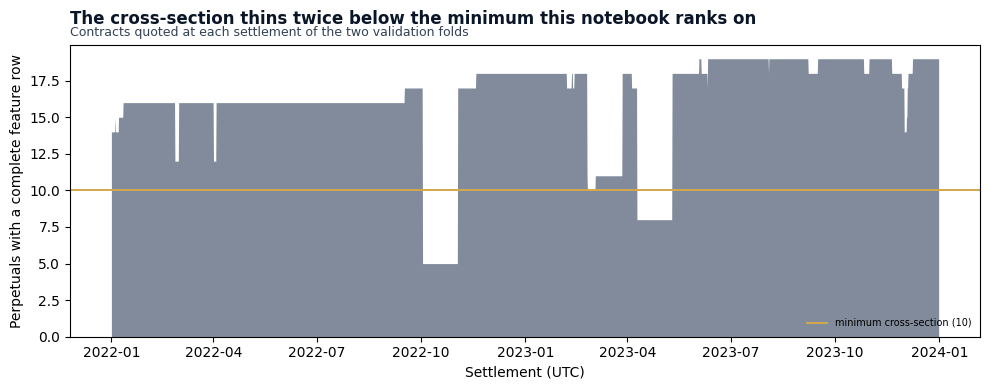

186 of 2189 settlements carry fewer than 10
smallest cross-section: 5 perpetuals


In [6]:
cross_section = (
    eval_panel.group_by("timestamp", "cv_fold").agg(pl.len().alias("perpetuals")).sort("timestamp")
)
thin = cross_section.filter(pl.col("perpetuals") < MIN_CROSS_SECTION)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(
    cross_section["timestamp"].to_list(),
    cross_section["perpetuals"].to_list(),
    color=COLORS["slate"],
    alpha=0.55,
    linewidth=0,
)
ax.axhline(
    MIN_CROSS_SECTION,
    color=COLORS["amber"],
    linewidth=1.4,
    label=f"minimum cross-section ({MIN_CROSS_SECTION})",
)
ax.set(xlabel="Settlement (UTC)", ylabel="Perpetuals with a complete feature row", ylim=(0, None))
ax.legend(frameon=False, fontsize=7, loc="lower right")
add_message_title(
    ax,
    "The cross-section thins twice below the minimum this notebook ranks on",
    subtitle="Contracts quoted at each settlement of the two validation folds",
)
fig.tight_layout()
show_with_alt(
    fig,
    "Filled area of contracts quoted per settlement across both validation folds, with a "
    "horizontal line at the minimum cross-section. Two runs of about a month fall below it.",
)

print(f"{thin.height} of {cross_section.height} settlements carry fewer than {MIN_CROSS_SECTION}")
print(f"smallest cross-section: {cross_section['perpetuals'].min()} perpetuals")

## 3. Can each feature be trusted, and can it be ranked?

Two different questions, and the notebook keeps them apart.

**Is the column usable?** Coverage is the share of rows where the feature has a value, and a
column below ninety per cent coverage, or with a single value throughout, fails and stops the
run. Staleness, the share of rows equal to the previous row for the same contract, is reported
and not enforced: the fee tier and the fitted volatility parameters are meant to persist, so a
repeated value is correct rather than a stale feed.

**Can the column rank contracts against each other?** The score used below is a correlation
computed *across* the contracts quoted at one settlement. A column that takes the same value
for every contract at that settlement carries no ordering, so no such correlation exists for it,
however informative it may be. Those columns are identified here rather than discovered as a
failure later, and they stay in the training frame.

In [7]:
quality_rows = []
ordered = eval_panel.sort(["symbol", "timestamp"])
for feature in mds.feature_names:
    unchanged = ordered.select(
        (pl.col(feature) == pl.col(feature).shift(1).over("symbol")).sum()
    ).item()
    varying_dates = (
        eval_panel.group_by("timestamp")
        .agg(pl.col(feature).drop_nulls().n_unique().alias("n_unique"))
        .filter(pl.col("n_unique") >= 2)
        .height
    )
    quality_rows.append(
        {
            "feature": feature,
            "source": "temporal" if feature in temporal_cols else "financial",
            "coverage": 1 - eval_panel[feature].null_count() / len(eval_panel),
            "staleness": unchanged / max(len(eval_panel) - eval_panel["symbol"].n_unique(), 1),
            "overall_unique": eval_panel[feature].drop_nulls().n_unique(),
            "varying_date_fraction": varying_dates / eval_panel["timestamp"].n_unique(),
        }
    )

quality = pl.DataFrame(quality_rows).with_columns(
    ((pl.col("coverage") >= 0.90) & (pl.col("overall_unique") >= 2)).alias("quality_pass"),
    (pl.col("varying_date_fraction") > 0).alias("cross_sectionally_identifiable"),
)
assert quality.filter(~pl.col("quality_pass")).is_empty()
display(
    quality.group_by("source").agg(
        pl.len().alias("features"),
        pl.col("coverage").min().alias("minimum coverage"),
        pl.col("staleness").max().alias("maximum staleness"),
        pl.col("cross_sectionally_identifiable").sum().alias("rankable"),
    )
)

source,features,minimum coverage,maximum staleness,rankable
str,u32,f64,f64,u32
"""financial""",39,1.0,1.0,37
"""temporal""",5,0.915391,0.914977,3


The columns that cannot be ranked are market-wide state: the settlement slot of the day and the
dispersion of funding across the universe are one number per settlement by construction, and
both regime probabilities from notebook 04 are fitted on the market rather than per contract.
They condition how a signal should be read, which is why they stay in the training frame, and
they simply have no cross-sectional score to report.

In [8]:
not_rankable = quality.filter(~pl.col("cross_sectionally_identifiable"))["feature"].to_list()
print(f"cannot be ranked across contracts: {', '.join(not_rankable)}")

cannot be ranked across contracts: funding_session, xs_funding_dispersion, hmm_regime_prob_calm, hmm_regime_prob_stress


## 4. The score: how well does a feature rank the next eight hours?

At each settlement, rank the contracts by the feature, rank them by the return they go on to
earn, and take the Spearman correlation of the two rankings. This is the **information
coefficient**, and it is deliberately a within-settlement quantity: it asks whether the feature
picks the better contract *right now*, not whether it moves with the market over time.
Repeating it at every settlement gives a series, and the feature's headline number is the
average of that series.

Averaging a series is only half of it. The average has a standard error, and the usual formula
for one assumes the settlements are independent. Two things here argue against that assumption
and they pull in opposite directions. Consecutive labels do not overlap, because `fwd_ret_8h`
spans exactly one settlement interval, so there is none of the artificial persistence that a
multi-day label would create. But funding settles three times a day and several features are
built from that cycle, so dependence at the scale of a funding day is expected. The standard
error below is therefore a **Newey-West** one, which widens or narrows the error bar according
to the correlation actually present in the series, at a bandwidth of one funding day.

In [9]:
rankable = quality.filter(pl.col("cross_sectionally_identifiable"))["feature"].to_list()
partitions = eval_panel.partition_by("timestamp", as_dict=True, maintain_order=True)
ic_results = {}
ic_timeseries = {}

for feature in rankable:
    observations = []
    for key, group in partitions.items():
        values = group.select(feature, mds.label_col, "cv_fold").drop_nulls()
        if len(values) < MIN_CROSS_SECTION or values[feature].n_unique() < 2:
            continue
        ic, _ = spearmanr(values[feature].to_numpy(), values[mds.label_col].to_numpy())
        if np.isfinite(ic):
            timestamp = key[0] if isinstance(key, tuple) else key
            observations.append(
                {
                    "timestamp": timestamp,
                    "cv_fold": values["cv_fold"][0],
                    "ic": ic,
                    "n_obs": len(values),
                }
            )
    if len(observations) >= MIN_IC_PERIODS:
        series = pl.DataFrame(observations).sort("timestamp")
        ic_results[feature] = compute_ic_hac_stats(series["ic"].to_numpy(), maxlags=HAC_MAXLAGS)
        ic_timeseries[feature] = series

scored_lengths = [series.height for series in ic_timeseries.values()]
print(f"{len(ic_results)} of {len(mds.feature_names)} features carry a score")
print(f"  {len(mds.feature_names) - len(rankable)} cannot be ranked across contracts")
print(f"  {len(rankable) - len(ic_results)} were rankable but had too few scored settlements")
print(
    f"scored settlements per feature: {min(scored_lengths):,} to {max(scored_lengths):,} "
    f"of {eval_panel['timestamp'].n_unique():,}"
)

40 of 44 features carry a score
  4 cannot be ranked across contracts
  0 were rankable but had too few scored settlements
scored settlements per feature: 1,903 to 2,003 of 2,189


### Is the score the same in both validation years?

The average above pools both folds. A feature that worked once and not again averages to the
same place as one that worked throughout, and only the fold-by-fold view separates them. With
two folds there is no distribution to summarize, so what is reported is simply whether the
fold averages agree in sign with the feature's own overall direction, in both, one or neither.
Comparing against the feature's *own* direction rather than against zero matters: a feature
that reliably ranks the contracts backwards is as stable as one that ranks them forwards, and
is just as usable once the model is allowed to trade it the other way.

In [10]:
fold_stats = {}
for feature, series in ic_timeseries.items():
    per_fold = series.group_by("cv_fold").agg(pl.col("ic").mean()).sort("cv_fold")
    fold_ics = per_fold["ic"].to_list()
    overall_sign = np.sign(ic_results[feature]["mean_ic"])
    fold_stats[feature] = {
        "sign_consistency": float(np.mean([np.sign(value) == overall_sign for value in fold_ics])),
    }

stable_count = sum(stats["sign_consistency"] == 1.0 for stats in fold_stats.values())
print(f"same score sign in both validation folds: {stable_count} of {len(fold_stats)}")

same score sign in both validation folds: 34 of 40


### The score series, before it is reduced

Everything from here on is a scalar summary of one object, the series computed above, so the
series is drawn first. Two patterns are visible in it and in nothing downstream of it: a score
that comes from a single episode and sits at zero either side of it, and a score that changes
sign between the two validation years. The band is the Newey-West interval around the average,
taken from the same call that produces the significance tests below, so the band and the tests
rest on one bandwidth.

The line is broken wherever the series is, which is at the two stretches section 2 identified
and at the join between the folds. Drawing through a break would suggest the notebook had
scored settlements it skipped.

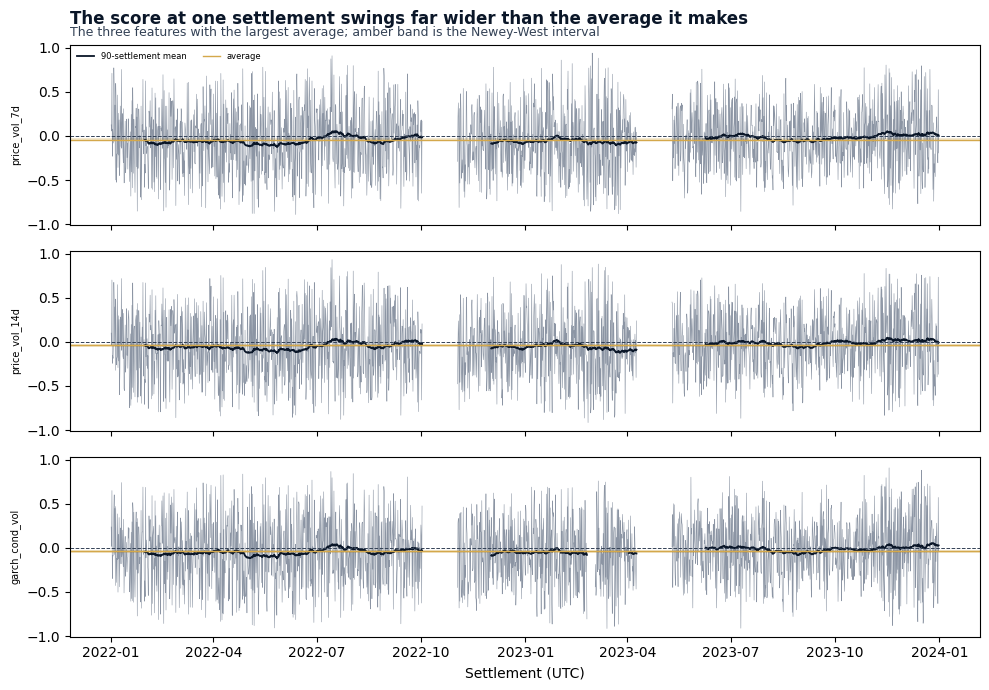

In [11]:
LEADING_FOR_SERIES = 3
ROLLING_BARS = 90  # thirty days at three settlements a day
eval_summary_ordering = sorted(ic_results, key=lambda name: -abs(ic_results[name]["mean_ic"]))
series_features = eval_summary_ordering[:LEADING_FOR_SERIES]


def contiguous_segments(series: pl.DataFrame) -> list[pl.DataFrame]:
    """Split a score series wherever it skips at least one settlement."""
    marked = series.sort("timestamp").with_columns(
        (pl.col("timestamp").diff() > timedelta(hours=BAR_HOURS))
        .fill_null(False)
        .cum_sum()
        .alias("_segment")
    )
    return [part.drop("_segment") for part in marked.partition_by("_segment", maintain_order=True)]


fig, axes = plt.subplots(len(series_features), 1, figsize=(10, 7), sharex=True, sharey=True)
for ax, feature in zip(axes, series_features, strict=True):
    stats = ic_results[feature]
    half_width = 1.96 * stats["hac_se"]
    for index, segment in enumerate(contiguous_segments(ic_timeseries[feature])):
        stamps = segment["timestamp"].to_list()
        ax.plot(stamps, segment["ic"].to_list(), color=COLORS["slate"], linewidth=0.4, alpha=0.5)
        ax.plot(
            stamps,
            segment["ic"].rolling_mean(ROLLING_BARS, min_samples=ROLLING_BARS).to_list(),
            color=COLORS["blue"],
            linewidth=1.3,
            label=f"{ROLLING_BARS}-settlement mean" if index == 0 else "_nolegend_",
        )
    ax.axhline(stats["mean_ic"], color=COLORS["amber"], linewidth=1.0, label="average")
    ax.axhspan(
        stats["mean_ic"] - half_width,
        stats["mean_ic"] + half_width,
        color=COLORS["amber"],
        alpha=0.25,
        lw=0,
    )
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
    ax.set_ylabel(feature, fontsize=7)
axes[0].legend(frameon=False, fontsize=6, ncols=2, loc="upper left")
axes[-1].set_xlabel("Settlement (UTC)")
add_message_title(
    axes[0],
    "The score at one settlement swings far wider than the average it makes",
    subtitle="The three features with the largest average; amber band is the Newey-West interval",
)
fig.tight_layout()
show_with_alt(
    fig,
    "Three stacked panels, one per feature, each showing the per-settlement score in grey, a "
    "rolling mean in blue, and a narrow amber band around the average near zero.",
)

### Fold by fold

The same evidence split in two. Each feature gets one point per validation year and a diamond
at its pooled average, so a feature whose two years land on opposite sides of zero is visible
as such rather than hidden inside an average.

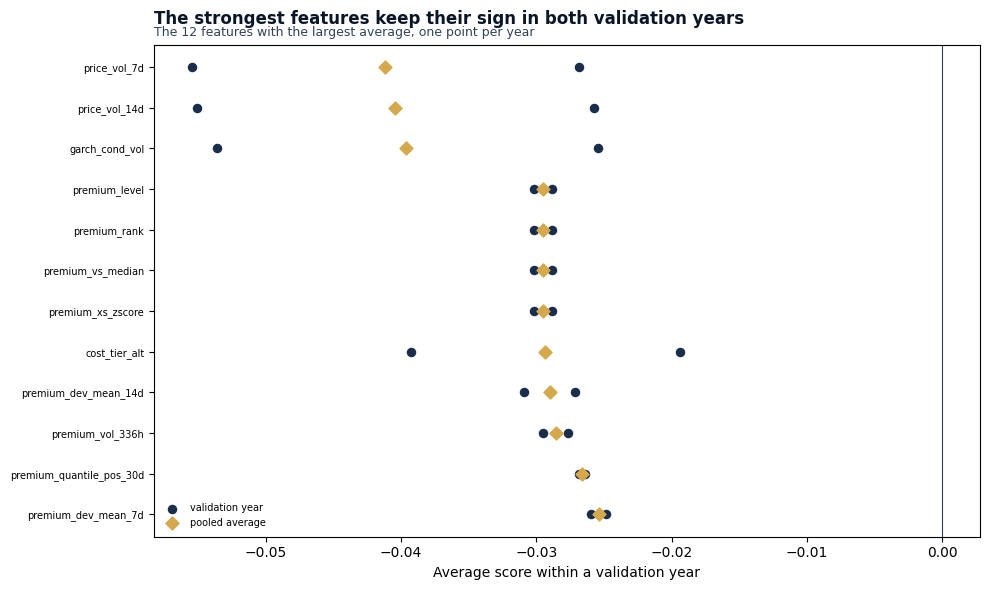

In [12]:
FOLD_FEATURES_SHOWN = 12
fold_features = [name for name in eval_summary_ordering if name in fold_stats][:FOLD_FEATURES_SHOWN]
fig, ax = plt.subplots(figsize=(10, 6))
for row, feature in enumerate(reversed(fold_features)):
    per_fold = (
        ic_timeseries[feature].group_by("cv_fold").agg(pl.col("ic").mean()).sort("cv_fold")["ic"]
    ).to_list()
    ax.scatter(
        per_fold,
        [row] * len(per_fold),
        color=COLORS["slate"],
        s=34,
        zorder=3,
        label="validation year" if row == 0 else "_nolegend_",
    )
    ax.scatter(
        [ic_results[feature]["mean_ic"]],
        [row],
        color=COLORS["amber"],
        marker="D",
        s=44,
        zorder=4,
        label="pooled average" if row == 0 else "_nolegend_",
    )
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set_yticks(range(len(fold_features)))
ax.set_yticklabels(list(reversed(fold_features)), fontsize=7)
ax.set_xlabel("Average score within a validation year")
ax.legend(frameon=False, fontsize=7, loc="lower left")
add_message_title(
    ax,
    "The strongest features keep their sign in both validation years",
    subtitle=f"The {FOLD_FEATURES_SHOWN} features with the largest average, one point per year",
)
fig.tight_layout()
show_with_alt(
    fig,
    "Horizontal strip plot of per-year average scores for the twelve strongest features, with a "
    "diamond marking each feature's pooled average. All points sit left of zero.",
)

## 5. Paying for the search

Forty features were scored, so the weakest of them would clear a five per cent significance
test roughly twice by chance alone. The **Benjamini-Hochberg** procedure controls that: instead
of asking whether each feature alone is unlikely under no relationship, it fixes the share of
false ones among those declared significant, and adjusts every test for the size of the set it
came from. The searched set here is those forty features on the primary label, and it is the
whole of what was looked at.

The naive and Newey-West counts below come from their own t-statistics; neither is read off the
other's p-values.

In [13]:
feature_names = list(ic_results)
hac_p_values = [ic_results[name]["p_value"] for name in feature_names]
naive_p_values = [2 * norm.sf(abs(ic_results[name]["naive_t_stat"])) for name in feature_names]
fdr_result = benjamini_hochberg_fdr(hac_p_values, alpha=0.05, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if name in temporal_cols else "financial" for name in feature_names],
        "mean_ic": [ic_results[name]["mean_ic"] for name in feature_names],
        "hac_t": [ic_results[name]["t_stat"] for name in feature_names],
        "hac_p": hac_p_values,
        "naive_t": [ic_results[name]["naive_t_stat"] for name in feature_names],
        "naive_p": naive_p_values,
        "fdr_p": list(fdr_result["adjusted_p_values"]),
        "fdr_sig": list(fdr_result["rejected"]),
    }
).sort(pl.col("mean_ic").abs(), descending=True)

n_naive = sum(value < 0.05 for value in naive_p_values)
n_hac = sum(value < 0.05 for value in hac_p_values)
n_fdr = int(fdr_result["n_rejected"])
leading = eval_summary.row(0, named=True)
print(f"significant at 5%: naive {n_naive}, Newey-West {n_hac}, after BH correction {n_fdr}")
print(f"largest average score: {leading['mean_ic']:.3f} on {leading['feature']}")

significant at 5%: naive 30, Newey-West 30, after BH correction 30
largest average score: -0.041 on price_vol_7d


### Sign first, then magnitude

The chart below is ordered by size, which makes it easy to miss that the sign is the same
throughout. Every one of the strongest features scores **negative**: contracts trading at a
high premium, paying high funding, or moving most violently are the ones that go on to earn
*less* over the next eight hours. That is the direction the crowding argument predicts, since a
rich premium is a payment longs are making to hold a position that is already popular. It also
means a model built on these features has to be free to sell them, and that a feature ranked by
the size of its score alone would hide the fact entirely.

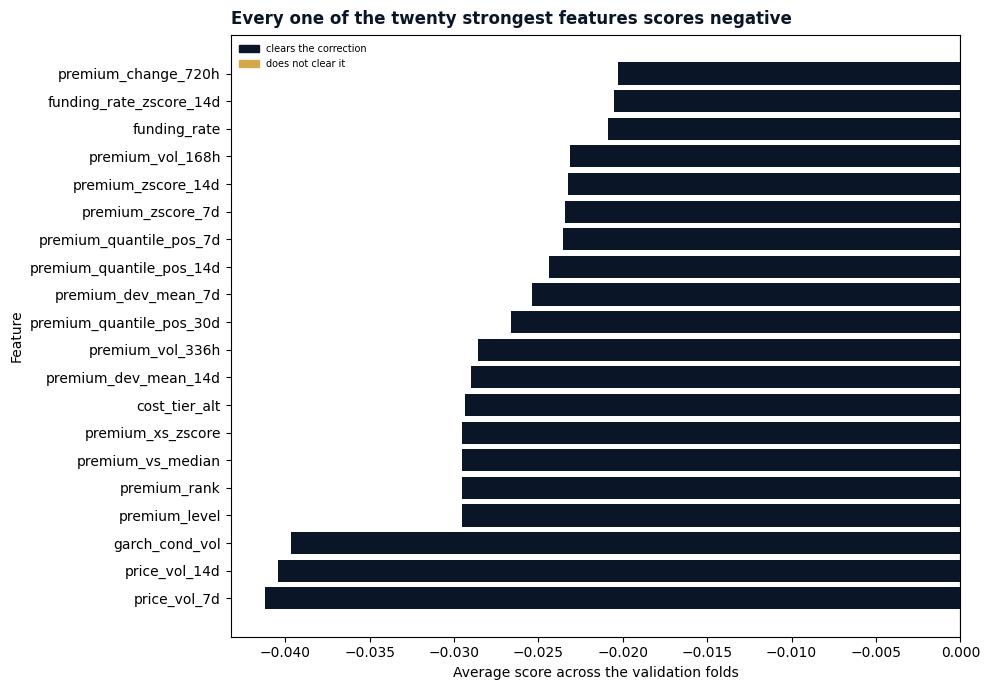

In [14]:
top_ic = eval_summary.head(20).sort("mean_ic")
fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [COLORS["blue"] if value else COLORS["amber"] for value in top_ic["fdr_sig"]]
ax.barh(top_ic["feature"].to_list(), top_ic["mean_ic"].to_list(), color=bar_colors)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set(xlabel="Average score across the validation folds", ylabel="Feature")
handles = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS["blue"]),
    plt.Rectangle((0, 0), 1, 1, color=COLORS["amber"]),
]
ax.legend(
    handles,
    ["clears the correction", "does not clear it"],
    frameon=False,
    fontsize=7,
    loc="upper left",
)
add_message_title(ax, "Every one of the twenty strongest features scores negative")
fig.tight_layout()
show_with_alt(
    fig,
    "Horizontal bars of the twenty largest average scores, all extending left of zero, coloured "
    "by whether the feature clears the multiple-testing correction.",
)

### What the correction for dependence costs, or pays

Plotting the two t-statistics against each other shows what the Newey-West standard error did to
each feature. Points on the diagonal were unaffected. Points below it, in this quadrant, are
features the correction made *more* significant, not less: the score series carries negative
dependence at the funding cycle, so treating settlements as independent understated the
precision of the average rather than overstating it. The shift is small, which is what a
non-overlapping label should produce.

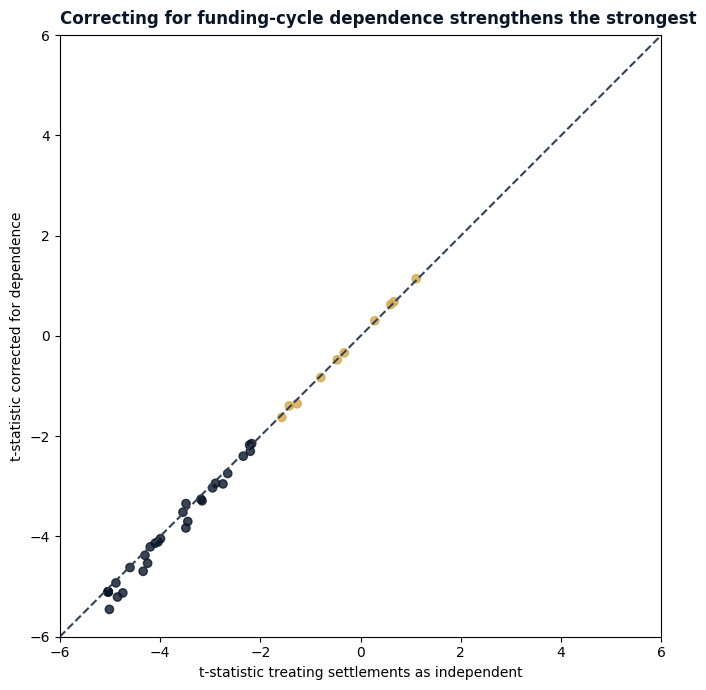

In [15]:
limit = 1.1 * max(eval_summary["naive_t"].abs().max(), eval_summary["hac_t"].abs().max())
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    eval_summary["naive_t"].to_list(),
    eval_summary["hac_t"].to_list(),
    color=[COLORS["blue"] if value else COLORS["amber"] for value in eval_summary["fdr_sig"]],
    alpha=0.8,
)
ax.plot([-limit, limit], [-limit, limit], color=COLORS["neutral"], linestyle="--")
ax.set(
    xlabel="t-statistic treating settlements as independent",
    ylabel="t-statistic corrected for dependence",
    xlim=(-limit, limit),
    ylim=(-limit, limit),
)
ax.set_aspect("equal", adjustable="box")
add_message_title(ax, "Correcting for funding-cycle dependence strengthens the strongest")
fig.tight_layout()
show_with_alt(
    fig,
    "Scatter of corrected against uncorrected t-statistics with a diagonal reference line. The "
    "largest negative points sit slightly below the diagonal.",
)

**40** of the **44** features carry a score; the other four take one value across the whole
cross-section at a settlement and cannot be ranked. Every score is computed on at most **2,003**
of the **2,189** settlements in the two validation years, because **186** of them offer fewer
than ten contracts. **30** of the 40 clear the Benjamini-Hochberg correction, and **34** hold
the same sign in both validation years. The largest average score is **-0.041**, on
`price_vol_7d`.

## 6. Is the relationship shaped like a ranking?

A rank correlation would look the same whether the effect sits in the extremes or spreads
evenly across the middle, and a strategy that goes long one end and short the other cares a
great deal which. So at each settlement the contracts are split into five equal groups by the
feature, and the return of each group is averaged over all settlements.

The group boundaries come from the contracts quoted at that settlement and from nothing else, so
the diagnostic asks the same question as the score it accompanies: given what is on the screen
right now, does the top group beat the bottom one?

A settlement offering fewer distinct values than there are groups cannot be split five ways, and
is left out. This matters more than it sounds: a feature that takes only two values, such as the
fee tier, would otherwise be split into five groups anyway, with the boundaries inside each tier
falling wherever the rows happened to be ordered. The result would be a shape the reader could
read and the data does not contain, so such a feature gets no profile and no `monotonicity`
value rather than a fabricated one.

Both the average and the median of each group are drawn. The average is what a book holding
every contract in the group earns; the median is where the typical contract ends up. Eight-hour
crypto returns have heavy tails, so the two can point in opposite directions, and where they do
the rank score sides with the median, because both ignore how far the extremes reach and it is
exactly that reach the average is picking up. The `monotonicity` column written to the ledger
is computed on the averages, which is the convention shared with the other eight case studies.

Features are chosen for this figure by score, skipping any whose score series is identical to
one already drawn. Four of the premium features produce the same ordering of contracts at every
settlement, so drawing them all would repeat one chart four times. Section 7 comes back to that.

In [16]:
FEATURES_SHAPED = 6


def quantile_profile(feature: str) -> tuple[pl.DataFrame, int, int]:
    """Average and median label by within-settlement group, and the settlements used."""
    valid = eval_panel.select("timestamp", feature, mds.label_col).drop_nulls()
    splittable = valid.filter(pl.col(feature).n_unique().over("timestamp") >= N_QUANTILES)
    ranked = splittable.with_columns(
        (
            (pl.col(feature).rank(method="ordinal").over("timestamp") - 1)
            * N_QUANTILES
            / pl.len().over("timestamp")
        )
        .floor()
        .clip(0, N_QUANTILES - 1)
        .cast(pl.Int8)
        .alias("quantile")
    )
    profile = (
        ranked.group_by("quantile")
        .agg(
            pl.col(mds.label_col).mean().alias("mean"),
            pl.col(mds.label_col).median().alias("median"),
        )
        .sort("quantile")
    )
    return profile, splittable["timestamp"].n_unique(), valid["timestamp"].n_unique()


shape_features: list[str] = []
quantile_profiles = {}
monotonicity = {}
too_coarse: list[str] = []
for candidate in eval_summary.filter(pl.col("fdr_sig"))["feature"].to_list():
    if any(
        ic_timeseries[candidate].height == ic_timeseries[chosen].height
        and np.allclose(ic_timeseries[candidate]["ic"], ic_timeseries[chosen]["ic"])
        for chosen in shape_features
    ):
        continue
    profile, used, available = quantile_profile(candidate)
    if profile.height < N_QUANTILES:
        too_coarse.append(candidate)
        continue
    means = profile["mean"].to_list()
    shape_features.append(candidate)
    quantile_profiles[candidate] = {
        "mean": means,
        "median": profile["median"].to_list(),
        "settlements": (used, available),
    }
    monotonicity[candidate] = float(spearmanr(range(len(means)), means).statistic)
    if len(shape_features) == FEATURES_SHAPED:
        break

print(f"profiles built for {len(shape_features)} features with distinct score series")
for feature in shape_features:
    used, available = quantile_profiles[feature]["settlements"]
    print(f"  {feature}: {used:,} of {available:,} settlements split {N_QUANTILES} ways")
if too_coarse:
    print(f"too few distinct values to split at any settlement: {', '.join(too_coarse)}")

profiles built for 6 features with distinct score series
  price_vol_7d: 2,189 of 2,189 settlements split 5 ways
  price_vol_14d: 2,189 of 2,189 settlements split 5 ways
  garch_cond_vol: 2,189 of 2,189 settlements split 5 ways
  premium_level: 2,185 of 2,189 settlements split 5 ways
  premium_dev_mean_14d: 2,189 of 2,189 settlements split 5 ways
  premium_vol_336h: 2,189 of 2,189 settlements split 5 ways
too few distinct values to split at any settlement: cost_tier_alt


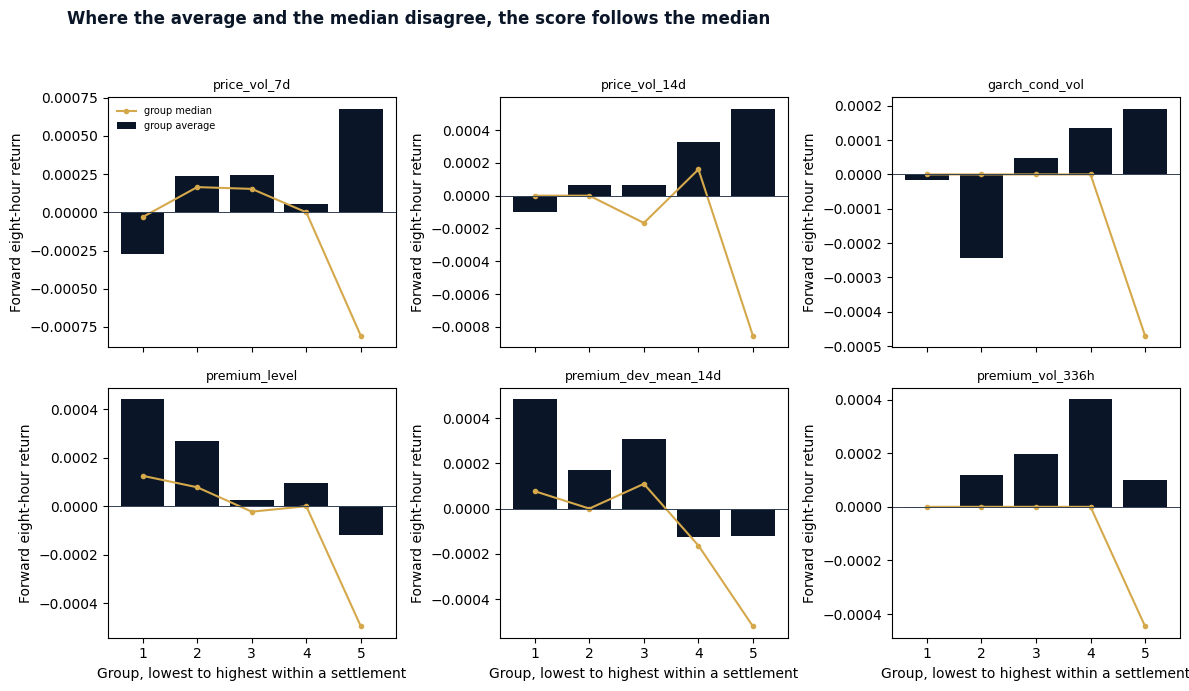

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True)
for ax, feature in zip(axes.flat, shape_features, strict=False):
    profile = quantile_profiles[feature]
    bins = range(1, len(profile["mean"]) + 1)
    ax.bar(bins, profile["mean"], color=COLORS["blue"], label="group average")
    ax.plot(
        bins,
        profile["median"],
        color=COLORS["amber"],
        marker="o",
        markersize=3,
        label="group median",
    )
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.7)
    ax.set_title(feature, fontsize=9)
    ax.set_ylabel("Forward eight-hour return")
for ax in axes[-1]:
    ax.set_xlabel("Group, lowest to highest within a settlement")
axes.flat[0].legend(frameon=False, fontsize=7)
for ax in axes.flat[len(shape_features) :]:
    ax.set_visible(False)
fig.suptitle(
    "Where the average and the median disagree, the score follows the median",
    x=0.06,
    ha="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
show_with_alt(
    fig,
    "Six small panels, one per feature, each with five bars for the group average return and an "
    "amber line for the group median across the same five groups.",
)

## 7. Which features are the same evidence twice?

Forty scores are not forty independent pieces of evidence. Features built from the same input
over overlapping windows move together, and a linear model given both cannot separate their
contributions. The pairwise rank correlation below is computed on a sample of roughly two
hundred settlements, which is enough to rank the pairs and cheap enough to compute over every
pair; the threshold above which a pair counts as redundant is the same one notebook 03 uses to
cut its redundancy tree, read from the configuration rather than retyped.

Each feature also carries a **family**, the group of features built from one input under one
hypothesis. The register lives in `config/setup.yaml` and notebook 03 assigns from it, so this
notebook assigns from the same register rather than restating it. The two families produced by
notebook 04 are added here, because they are the output of a model rather than a construction
from the price and funding record.

In [18]:
families = dict(assign_families(financial_cols, FAMILY_REGISTER))
families.update(
    {name: "temporal_volatility" for name in temporal_cols if name.startswith("garch_")}
)
families.update({name: "temporal_regime" for name in temporal_cols if name.startswith("hmm_")})
assert set(families) == set(mds.feature_names)
display(
    pl.DataFrame({"feature": list(families), "family": list(families.values())})
    .group_by("family")
    .agg(pl.len().alias("features"))
    .sort("family")
)

family,features
str,u32
"""carry""",9
"""cross_sectional""",3
"""mean_reversion""",6
"""momentum""",8
"""regime""",5
"""temporal_regime""",2
"""temporal_volatility""",3
"""volatility""",8


In [19]:
sample_dates = (
    eval_panel["timestamp"]
    .unique()
    .sort()
    .gather_every(max(1, eval_panel["timestamp"].n_unique() // 200))
)
correlation_sample = eval_panel.filter(pl.col("timestamp").is_in(sample_dates))
high_corr_pairs = []
for left_idx, left in enumerate(rankable):
    for right in rankable[left_idx + 1 :]:
        pair = correlation_sample.select(left, right).drop_nulls()
        if len(pair) < MIN_IC_PERIODS:
            continue
        correlation = float(spearmanr(pair[left].to_numpy(), pair[right].to_numpy()).statistic)
        if np.isfinite(correlation) and abs(correlation) > REDUNDANCY_CUT:
            high_corr_pairs.append((left, right, correlation))

high_corr_pairs.sort(key=lambda item: abs(item[2]), reverse=True)
print(f"{len(high_corr_pairs)} pairs correlate above {REDUNDANCY_CUT:.2f} in absolute value")
print(f"measured on {len(sample_dates)} sampled settlements")

45 pairs correlate above 0.70 in absolute value
measured on 219 sampled settlements


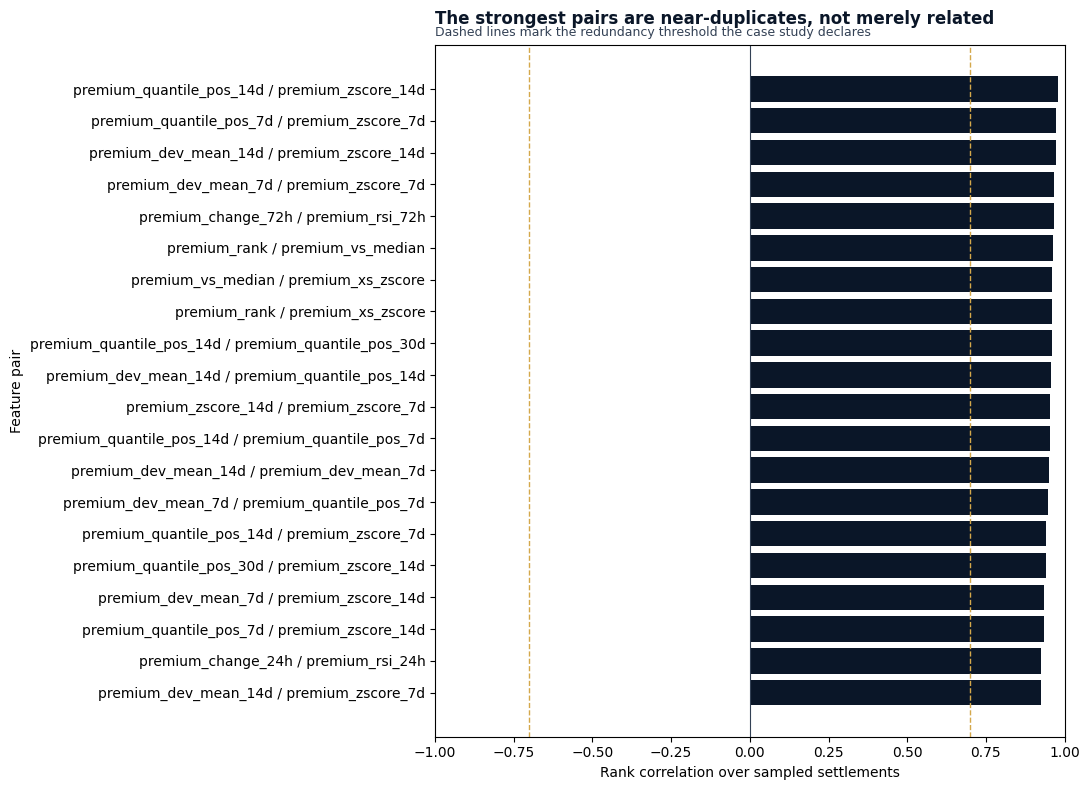

In [20]:
pair_plot = high_corr_pairs[:20][::-1]
pair_labels = [f"{left} / {right}" for left, right, _ in pair_plot]
pair_values = [value for _, _, value in pair_plot]
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(
    pair_labels,
    pair_values,
    color=[COLORS["blue"] if value >= 0 else COLORS["amber"] for value in pair_values],
)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.axvline(REDUNDANCY_CUT, color=COLORS["amber"], linewidth=1.0, linestyle="--")
ax.axvline(-REDUNDANCY_CUT, color=COLORS["amber"], linewidth=1.0, linestyle="--")
ax.set(xlabel="Rank correlation over sampled settlements", ylabel="Feature pair", xlim=(-1, 1))
add_message_title(
    ax,
    "The strongest pairs are near-duplicates, not merely related",
    subtitle="Dashed lines mark the redundancy threshold the case study declares",
)
fig.tight_layout()
show_with_alt(
    fig,
    "Horizontal bars of the twenty most strongly correlated feature pairs, all positive and "
    "close to one, with dashed lines at the declared redundancy threshold.",
)

A pairwise correlation over pooled settlements understates the sharpest case. Four premium
features - the level, its cross-sectional rank, its distance from the cross-sectional median
and its cross-sectional z-score - are each a strictly increasing function of the same quantity
*within* a settlement. They therefore produce one ordering of the contracts, one score at every
settlement, and one row of evidence between them, even though their pooled correlation is below
one because the mapping differs from settlement to settlement. Counting them as four is what
the search accounting in section 5 does, and it is conservative in the right direction.

In [21]:
identical_groups: dict[str, list[str]] = {}
for feature in eval_summary_ordering:
    for representative, members in identical_groups.items():
        if ic_timeseries[feature].height == ic_timeseries[representative].height and np.allclose(
            ic_timeseries[feature]["ic"], ic_timeseries[representative]["ic"]
        ):
            members.append(feature)
            break
    else:
        identical_groups[feature] = [feature]
display(
    pl.DataFrame(
        [
            {"features carrying one ordering": ", ".join(members), "count": len(members)}
            for members in identical_groups.values()
            if len(members) > 1
        ]
    )
)

features carrying one ordering,count
str,i64
"""premium_level, premium_rank, p…",4


## 8. The ledger

Every feature gets a decision and the evidence behind it, written to
`evaluation/triage_ledger.parquet`. Chapter 20 reads that file for all nine case studies at once
and builds its comparison from it.

The rule has two ways to reach `PROCEED`, and they answer different questions. The first is the
**confirmation** arm: the feature cleared the correction for the size of the search, so its
score is unlikely to be an artifact of having looked at forty things. The second is the
**exploration** arm: the feature held its sign in both validation years and its average score
clears the exploration threshold printed at the top of the notebook in absolute value. That
threshold is a judgment, not an inference. It exists so
that a small cross-section, where almost nothing clears a corrected significance test, does not
leave the next stage with nothing to model, and it is set an order of magnitude below the
strongest scores here and an order of magnitude above the ones indistinguishable from zero. A
feature promoted this way has not been confirmed, and the ledger's `note` column records which
arm fired so that a reader can tell the two apart.

`REVISE` is not a rejection. It says the feature has no univariate evidence of its own, which is
the expected outcome for a conditioning variable whose job is to change how another feature
should be read.

The third outcome the book's rule defines, `STOP`, is for a feature whose column cannot be
trusted. It does not appear in this ledger, because the completeness check in section 3 raises
rather than passing such a column through to here.

None of the three filters anything. The model notebooks train on all forty-four features. Making
this a selection step would choose features on the same validation years the models are then
scored on, which is how a validation result stops meaning anything.

In [22]:
def assign_triage(feature: str, quality_row: dict, result: dict | None) -> tuple[str, str]:
    """Apply the book's triage rule without changing the model input contract."""
    if not quality_row["quality_pass"]:
        return "STOP", "quality_failure"
    if result is None:
        return "REVISE", "conditioning_not_cross_sectional"
    is_fdr = bool(fdr_lookup[feature]["fdr_sig"])
    stable = fold_stats[feature]["sign_consistency"] == 1.0
    above_threshold = abs(result["mean_ic"]) >= IC_THRESHOLD
    if is_fdr:
        return "PROCEED", "fdr_significant"
    if stable and above_threshold:
        return "PROCEED", "stable_above_threshold"
    return "REVISE", "weak_univariate"

In [23]:
fdr_lookup = {row["feature"]: row for row in eval_summary.to_dicts()}
ledger_rows = []
for feature in mds.feature_names:
    quality_row = quality.filter(pl.col("feature") == feature).row(0, named=True)
    result = ic_results.get(feature)
    decision, note = assign_triage(feature, quality_row, result)
    ledger_rows.append(
        {
            "feature": feature,
            "family": families[feature],
            "source": quality_row["source"],
            "mean_ic": None if result is None else result["mean_ic"],
            "hac_t": None if result is None else result["t_stat"],
            "fdr_p": None if result is None else fdr_lookup[feature]["fdr_p"],
            "sign_consistency": None if result is None else fold_stats[feature]["sign_consistency"],
            "monotonicity": monotonicity.get(feature),
            "coverage": quality_row["coverage"],
            "staleness": quality_row["staleness"],
            "decision": decision,
            "note": note,
        }
    )

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")
display(triage_ledger.group_by("decision", "note").len().sort("decision", "note"))

decision,note,len
str,str,u32
"""PROCEED""","""fdr_significant""",30
"""PROCEED""","""stable_above_threshold""",2
"""REVISE""","""conditioning_not_cross_section…",4
"""REVISE""","""weak_univariate""",8


In [24]:
ic_ts_all = pl.concat(
    [
        series.with_columns(pl.lit(feature).alias("feature"))
        for feature, series in ic_timeseries.items()
    ]
)
ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
print(f"triage ledger: {len(triage_ledger)} features")
print(f"score series: {len(ic_ts_all):,} feature-settlements")

triage ledger: 44 features
score series: 79,939 feature-settlements


The ledger records **32** features at `PROCEED` and **12** at `REVISE`. **30** of the 32 were
promoted by clearing the correction for the size of the search, and the other **2** by the
exploration arm; **4** of the 12 are the market-wide columns with no cross-sectional score at
all. **45** feature pairs correlate above **0.70** in absolute value, and **4** premium features
produce one and the same ordering of the contracts, so the forty-four columns carry
substantially fewer than forty-four distinct pieces of evidence.

## Key takeaways

1. **Score a feature the way the strategy will use it.** The strategy ranks contracts against
   each other at one settlement, so the score is a correlation across contracts at one
   settlement, averaged over settlements. Every diagnostic built on top of it - the group
   profile, the redundancy check - is built the same way, so they answer one question rather
   than three that happen to agree.
2. **Build the evaluation frame from the folds, not from the calendar.** Where a feature is
   itself fitted per fold, a row is out of sample only in the fold that tests it, and using one
   fold's version of the column everywhere quietly scores a model on its own training data.
3. **The error bar is part of the estimate.** The average of a score series is easy; whether the
   settlements are independent enough to average that way is the question, and it is answered by
   the dependence actually present in the series rather than assumed away.
4. **Adjust for the size of the search and say what the size was.** A significance claim with no
   statement of how many candidates were tried cannot be interpreted, and the number of features
   scored is not the same as the number searched when several are the same ordering in disguise.
5. **Screening is not selection.** The ledger is a record. Filtering the training matrix on
   validation evidence, and then measuring the model on the same validation years, is the
   mistake this separation exists to prevent.

**Known limitations**

- Univariate screening cannot see an interaction. A feature that only works in one regime, or
  only in combination with another, scores near zero here and may still be useful. Chapters 11
  and 12 make the decisive judgments.
- Two folds is enough to tell "worked twice" from "worked once" and not enough for a
  distribution. An interquartile range across two numbers would be an ornament.
- The score is measured on the settlements where at least ten contracts are quoted, which
  excludes two stretches of about a month. Whatever happened in those stretches is not in any
  number here.
- Nothing in this notebook says a feature is tradable. A score of the size seen here has to
  survive costs, position sizing and turnover before it earns anything, and those are the
  subject of the backtest notebooks.

**Next**: [`06_linear`](06_linear.ipynb) fits the first models on the full forty-four-column
frame.